# Прогнозирование оттока клиентов банка

Проанализированы клиенты, обслуживающихся в многонациональном банке ABC. Цель данной работы — прогнозирование оттока клиентов.  
Для этого выполнен исследовательский анализ данных и предобработка.  
Для прогнозирования применены модели дерева решений, случаного леса с поиском гиперпараметров по сетке, градиентного бустинга с отбором признаков, что позволило улучшить прогноз. Также использован модуль AutoML, который автоматически обрабатывает данные и строит прогноз.      
Модели градиентного бустинга показали наилучшие результаты: доля правильно предсказанного оттока составила 50%.  
Проведена кластеризация клиентов и сравнительный анализ кластеров.

In [ ]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import requests
import torch

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

import warnings
# Отключение предупреждений (warnings)
warnings.filterwarnings("ignore")

Содержание  
- Исследование данных
- Прогнозирование оттока
    - Дерево решений (DecisionTree)
    - Случайный лес (RandomForest)
    - градиентный бустинг (CatBoost)
    - AutoML (lightautoml)
- Кластеризация (DBSCAN)

In [2]:
# импорт данных (с сайта kaggle.com)
df = pd.read_csv('Bank Customer Churn Prediction.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


Структура данных:  

- customer_id,   
- credit_score,   
- country,   
- gender,   
- age,  
- tenure,   
- balance,  
- products_number,   
- credit_card,   
- active_member,   
- estimated_salary,   
- churn 1, если клиент покинул банк за определенный период, или 0, если нет.

In [4]:
df.describe(include='all').round()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.0,10000.0,10000,10000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,15690941.0,651.0,NaN,NaN,39.0,5.0,76486.0,2.0,1.0,1.0,100090.0,0.0
std,71936.0,97.0,NaN,NaN,10.0,3.0,62397.0,1.0,0.0,0.0,57510.0,0.0
min,15565701.0,350.0,NaN,NaN,18.0,0.0,0.0,1.0,0.0,0.0,12.0,0.0
25%,15628528.0,584.0,NaN,NaN,32.0,3.0,0.0,1.0,0.0,0.0,51002.0,0.0
50%,15690738.0,652.0,NaN,NaN,37.0,5.0,97199.0,1.0,1.0,1.0,100194.0,0.0
75%,15753234.0,718.0,NaN,NaN,44.0,7.0,127644.0,2.0,1.0,1.0,149388.0,0.0


In [5]:
df.duplicated().sum()

0

Пропусков в данных нет, отрицательных значений нет, дупликатов тоже нет. Но есть категориальные поля *country* и *gender*, которые необходимо предобработать, например, перевести в числовые категориии.

Сейчас удалим ненужное для моделей поле - *customer_id*, и исследуем данные.

In [6]:
df.drop(columns='customer_id', inplace=True)

## Исследование данных

In [7]:
df.churn.value_counts(normalize=True)

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Есть смещение по целевому признаку (оттоку): 80% активные и 20% ушедшие - большой дисбаланс, который необходимо учитывать при оценке моделей.

<Axes: >

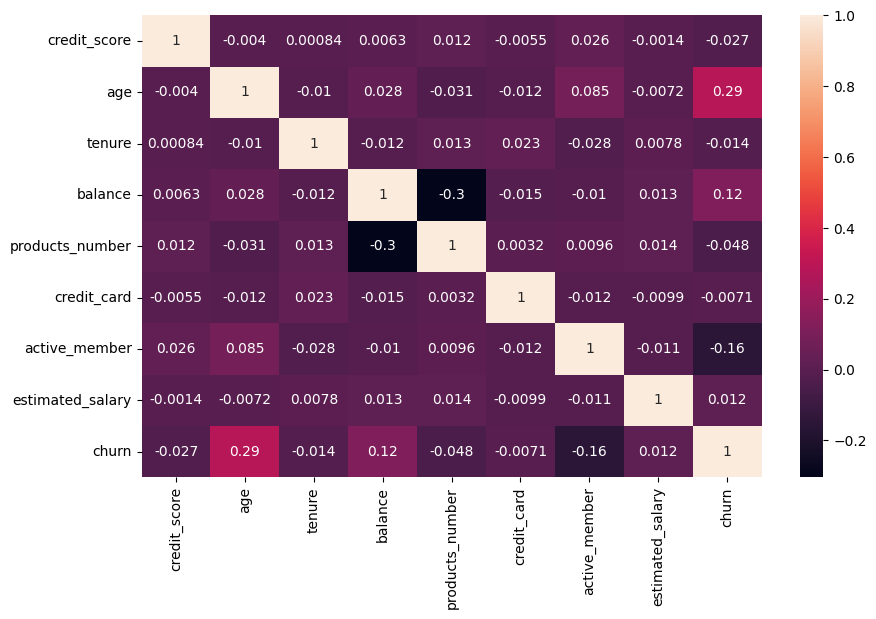

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['country','gender']).corr(),annot=True)

Сильно скоррелированных признаков нет, но есть небольшая корреляция между *balance* и *products_number* и между возрастом и числом ушедших клиентов.

Посмотрим на распределение признаков по оттоку.

In [9]:
# выделим категориальные и не категориальные признаки
cat_col = [col for col in df.drop(columns='churn').columns if df[col].nunique() <= 11]
not_cat_col = [col for col in df.drop(columns='churn').columns if df[col].nunique() > 11]

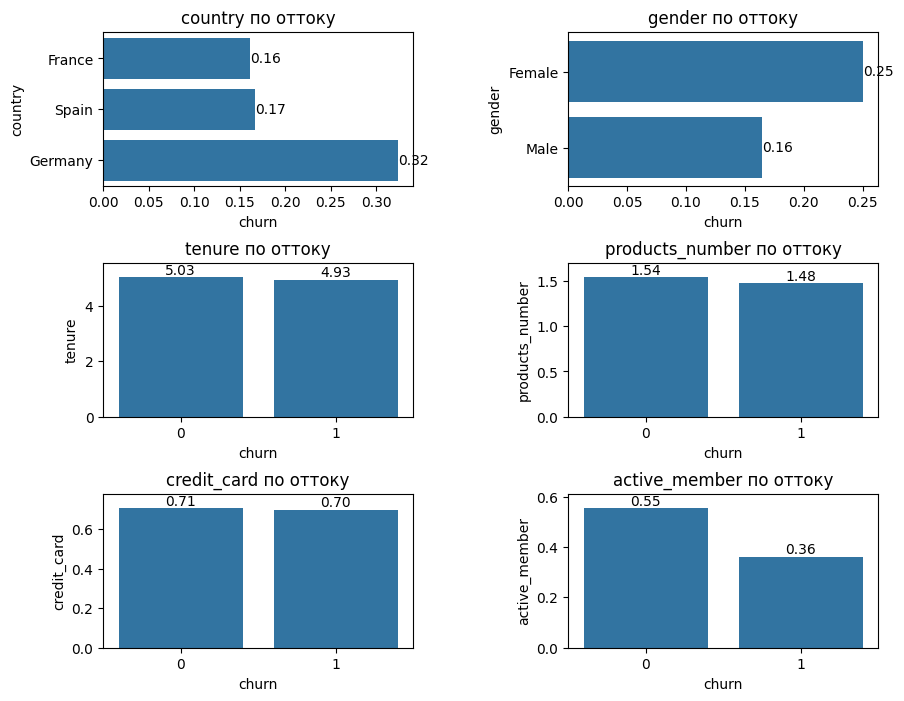

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ax = sns.barplot(data=df, x='churn', y=col, ax=axes[i], errorbar=None,)
    ax.set_title(f'{col} по оттоку')
    bar_labels = [f'{v:.2f}' for v in ax.containers[0].datavalues]
    ax.bar_label(ax.containers[0], labels=bar_labels)
    y_lim = ax.get_ylim()
    ax.set_ylim(y_lim[0], y_lim[1]*1.05)

# убираем лишние пустые оси
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

Среди немцев больше доля оттока - 32%, в Испании и Франции - по 16-17%. Женщины чаще уходят: четверть из них ушли, среди мужчин таких 16%. 

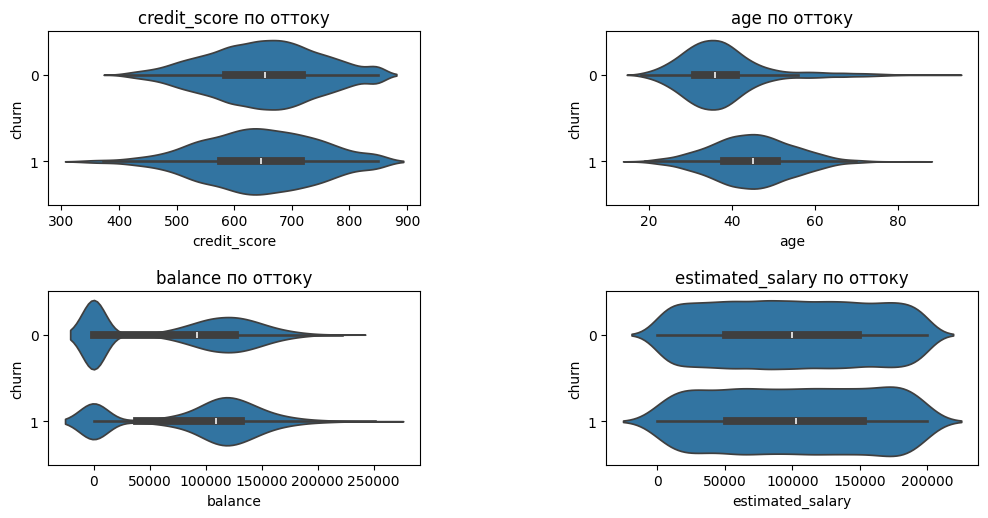

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(not_cat_col):
    ax = sns.violinplot(data=df, y='churn', x=col, orient='h', ax=axes[i])
    ax.set_title(f'{col} по оттоку')

# убираем лишние пустые оси
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

Средний возраст ушедиших клиентов больше, чем не ушедших. Средний *balance* также больше у ушедших клиентов, а среди не покинувших банк больше клиентов с нулевым балансом.

## ML прогнозирование оттока

Подготовим данные для моделей: преобразуем категориальные признаки в числовые, разделим данные на обучающую и тестовую выборку, учитывая дисбаланс по целевому признаку

In [12]:
le = LabelEncoder()
df_le = df.copy()
df_le['country'] = le.fit_transform(df_le.country)
df_le['gender'] = le.fit_transform(df_le.gender)

In [13]:
df_le.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df_le.drop(columns='churn'), df_le.churn,
    random_state=42, test_size=0.2, stratify=df_le.churn
)

In [15]:
def print_metrics(y_test_pred, y_train_pred):
    '''Функция вывода основных метрик'''
    # метрики точности и полноты
    print(classification_report(y_test, y_test_pred))
    print('F1 мера на обучающем наборе', 
          round(f1_score(y_train, y_train_pred),3))
    print('F1 мера на тесте', 
          round(f1_score(y_test, y_test_pred), 3))
    # матрица разброса для оценки точности
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(3,2))
    sns.heatmap(cm, annot=True, fmt='', cmap='Blues')
    plt.xlabel('прогноз')
    plt.ylabel('факт')
    plt.show()

Построим прогноз с помощью дерева решений с подбором гиперпараметров по сетке и по лучшей модели построим прогноз

### дерево решений

In [16]:
%%time
# дерево решений
dt = DecisionTreeClassifier(random_state=42)
dt_cv = GridSearchCV(dt, {'max_depth': [10,100,500],
                        'min_samples_leaf': [1,40,100],
                        'criterion': ['gini', 'enthropy'],
                        'max_features': [3,7,None]},
                    cv=5, scoring='f1', n_jobs=-1)
dt_cv.fit(X_train, y_train)
print('лучшие параметры', dt_cv.best_params_)
print('F1', dt_cv.best_score_)

лучшие параметры {'criterion': 'gini', 'max_depth': 100, 'max_features': 7, 'min_samples_leaf': 40}
F1 0.5557135074364312
CPU times: total: 391 ms
Wall time: 3.56 s


              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.70      0.44      0.54       407

    accuracy                           0.85      2000
   macro avg       0.79      0.70      0.73      2000
weighted avg       0.84      0.85      0.83      2000

F1 мера на обучающем наборе 0.585
F1 мера на тесте 0.544


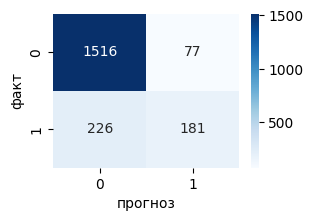

In [17]:
dt_best = dt_cv.best_estimator_
dt_best.fit(X_train, y_train)
dt_cv_test_pred = dt_best.predict(X_test)
dt_cv_train_pred = dt_best.predict(X_train)
print_metrics(dt_cv_test_pred,dt_cv_train_pred)

Модель больше чем в половине случаев ошибается при прогнозе оттока. F1 мера - 0,54, а *recall* - доля правильно спрогнозированного класса 1 - всего 0,44.

Построим прогноз с помощью модели случайного леса

### случайный лес

In [18]:
%%time
# случайный лес
rf = RandomForestClassifier(random_state=42)
grid_params = {'n_estimators':[100,150,200],
                'max_depth': [5,10,None],
                'min_samples_split': [20,25,30],
                'max_features': [6,8,None]}
rf_cv = GridSearchCV(rf, grid_params,
                    cv=5, scoring='f1', n_jobs=-1)
rf_cv.fit(X_train, y_train)
print('лучшие параметры', rf_cv.best_params_)
print('best_score', rf_cv.best_score_)

лучшие параметры {'max_depth': None, 'max_features': 6, 'min_samples_split': 25, 'n_estimators': 200}
best_score 0.5780183353243663
CPU times: total: 3.33 s
Wall time: 1min 36s


              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

F1 мера на обучающем наборе 0.695
F1 мера на тесте 0.572


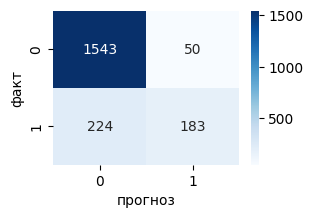

In [19]:
rf_best = rf_cv.best_estimator_
rf_best.fit(X_train, y_train)
rf_best_test_pred = rf_best.predict(X_test)
rf_best_train_pred = rf_best.predict(X_train)
print_metrics(rf_best_test_pred, rf_best_train_pred)

Прогноз оттока также плохо прогнозируется - *recall* всего 0,45, также модель случайного леса сильнее переобучается, чем дерево: разница F1 меры между train и test у RandomForest - 0,123, а у дерева - 0,041.

Попробуем применить градиентный бустинг - модель CatBoostClassifier.

### Градиентный бустинг

In [20]:
train_pool = Pool(data=X_train, label=y_train)
test_pool = Pool(data=X_test, label=y_test)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

F1 мера на обучающем наборе 0.74
F1 мера на тесте 0.592


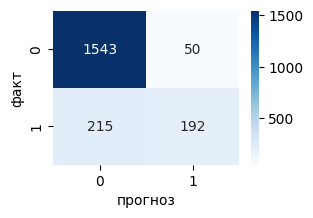

In [21]:
cbc = CatBoostClassifier(random_state=42,
                        iterations=1000,
                        thread_count=-1, 
                        loss_function='Logloss',
                        verbose=False, 
                        eval_metric='F1', 
                        early_stopping_rounds=200)
cbc.fit(train_pool)
cbc_test_pred = cbc.predict(test_pool)
cbc_train_pred = cbc.predict(train_pool)
print_metrics(cbc_test_pred, cbc_train_pred)

Модель взята с гиперпараметрами по умолчанию, ее результаты лучше модели случайного леса: *recall* вырос на 0,02 до 0,47.  
Попробуем отобрать такие признаки, чтобы улучшиьть этот показатель. Для этого возьмем SHAP значения признаков из обученной только что модели Catboost, усредним эти значения по каждому признаку и выведем по значимости, от высокого до низкого.

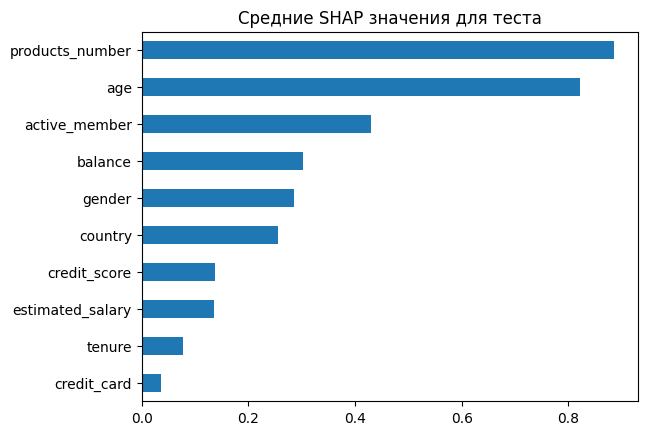

In [22]:
pd.DataFrame(cbc.get_feature_importance(
        data=test_pool,
        type="ShapValues",
    ), columns=list(X_test.columns)+ ['base_value']
).abs().mean().sort_values()\
.drop('base_value', axis=0)\
.plot(kind='barh')
plt.title('Средние SHAP значения для теста')
plt.show()

Оставим первые топ-6 признаков и снова обучим модель.

In [23]:
selected_features = ['products_number','age',
                     'active_member','balance',
                     'gender','country']
train_top6_pool = Pool(X_train[selected_features], y_train)
test_top6_pool = Pool(X_test[selected_features], y_test)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.50      0.60       407

    accuracy                           0.86      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.86      0.85      2000

F1 мера на обучающем наборе 0.665
F1 мера на тесте 0.599


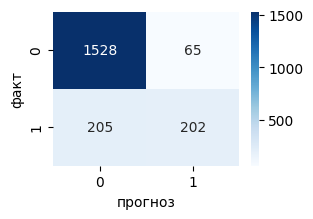

In [ ]:
cbc_top_6 = CatBoostClassifier(random_state=42,
                        iterations=600,
                        thread_count=-1, 
                        loss_function='Logloss',
                        verbose=False, 
                        eval_metric='F1', 
                        early_stopping_rounds=200)
cbc_top_6.fit(train_top6_pool)
cbc_top_6_test_pred = cbc_top_6.predict(test_top6_pool)
cbc_top_6_train_pred = cbc_top_6.predict(train_top6_pool)
print_metrics(cbc_top_6_test_pred, cbc_top_6_train_pred)

Немного лучше: *recall* вырос еще на 0,02 до 0,49, к тому же модель не так сильно переобучается: F1 мера на train данных снизилась с 0,74 до 0,696.

### AutoML

Попробуем построить прогноз с помощью AutoML системы, которая самостоятельно обрабатывает признаки, обучает разные модели, автоматически подбирает гиперпараметры и использует финальный ансамбль с лучшей метрикой

In [ ]:
# LightAutoML presets, task and report generation
from lightautoml.automl.presets.tabular_presets import TabularAutoML, TabularUtilizedAutoML
from lightautoml.tasks import Task
from lightautoml.report.report_deco import ReportDeco, ReportDecoUtilized
from lightautoml.addons.tabular_interpretation import SSWARM

'nlp' extra dependency package 'fasttext-numpy2' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


In [31]:
df_train = X_train.join(y_train)
df_test = X_test.join(y_test)

In [ ]:
%%time
automl = TabularAutoML(
    task=Task(name='binary', 
        metric=lambda y_true, y_pred: f1_score(y_true, (y_pred > 0.5)*1)),
    reader_params={'n_jobs': 4, 'cv': 5, 'random_state': 42}
)
fold_predict = automl.fit_predict(
    df_train, roles={'target': 'churn'}, verbose = 1
)

[13:06:21] Stdout logging level is INFO.
[13:06:21] Task: binary

[13:06:21] Start automl preset with listed constraints:
[13:06:21] - time: 3600.00 seconds
[13:06:21] - CPU: 4 cores
[13:06:21] - memory: 16 GB

[13:06:21] Train data shape: (8000, 11)



[13:06:24] Layer 1 train process start. Time left 3596.44 secs
[13:06:24] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[13:06:24] Fitting Lvl_0_Pipe_0_Mod_0_LinearL2 finished. score = 0.0
[13:06:24] Lvl_0_Pipe_0_Mod_0_LinearL2 fitting and predicting completed
[13:06:24] Time left 3596.09 secs

[13:06:26] Selector_LightGBM fitting and predicting completed
[13:06:26] Start fitting Lvl_0_Pipe_1_Mod_0_LightGBM ...
[13:06:34] Fitting Lvl_0_Pipe_1_Mod_0_LightGBM finished. score = 0.5869894099848714
[13:06:34] Lvl_0_Pipe_1_Mod_0_LightGBM fitting and predicting completed
[13:06:34] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ... Time budget is 300.00 secs


Optimization Progress: 100%|██████████| 101/101 [02:46<00:00,  1.65s/it, best_trial=51, best_value=0.616]

[13:09:20] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[13:09:20] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[13:09:23] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = 0.5907553551296505
[13:09:23] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[13:09:23] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[13:09:25] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = 0.5823754789272031
[13:09:25] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[13:09:25] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 300.00 secs


Optimization Progress: 100%|██████████| 101/101 [01:05<00:00,  1.54it/s, best_trial=89, best_value=0.611]

[13:10:31] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[13:10:31] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[13:10:35] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = 0.5885455915599096
[13:10:35] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[13:10:35] Time left 3345.12 secs

[13:10:35] Layer 1 training completed.

[13:10:35] Blending: optimization starts with equal weights. Score = 0.5589661
[13:10:36] Blending: iteration 0: score = 0.5916131, weights = [0.         0.3363388  0.61313    0.         0.05053126]
[13:10:36] Blending: no improvements for score. Terminated.

[13:10:36] Blending: best score = 0.5916131, best weights = [0.         0.3363388  0.61313    0.         0.05053126]
[13:10:36] Automl preset training completed in 255.04 seconds

[13:10:36] Model description:
Final prediction for new objects (level 0) = 
	 0.33634 * (5 averaged models Lvl_0_Pipe_1_Mod_0_LightGBM) +
	 0.61313 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.05053 * (5 averaged models Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost) 

CPU times: total: 16min 56s
Wall time: 4min

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000

F1 мера на обучающем наборе 0.668
F1 мера на тесте 0.612


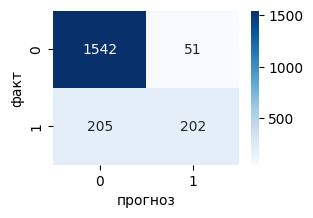

In [69]:
automl_test_pred = (automl.predict(df_test).data[:,0]>0.5)*1
automl_train_pred = (automl.predict(df_train).data[:,0]>0.5)*1
print_metrics(automl_test_pred, automl_train_pred)

AutoML использовала модели градиентного бустинга, в основном, LightGBM. Получены те же результаты по *recall*, но снизились ошибки на ложно положительных предсказаниях.

## Кластеризация

Попробуем кластеризировать пользователей и посмотрим разницу в кластерах.  

Сначала стандартизируем.

In [27]:
sc = StandardScaler()

X_cluster = sc.fit_transform(df_le.drop(columns='churn'))
X_cluster[:5]

array([[-0.32622142, -0.90188624, -1.09598752,  0.29351742, -1.04175968,
        -1.22584767, -0.91158349,  0.64609167,  0.97024255,  0.02188649],
       [-0.44003595,  1.51506738, -1.09598752,  0.19816383, -1.38753759,
         0.11735002, -0.91158349, -1.54776799,  0.97024255,  0.21653375],
       [-1.53679418, -0.90188624, -1.09598752,  0.29351742,  1.03290776,
         1.33305335,  2.52705662,  0.64609167, -1.03067011,  0.2406869 ],
       [ 0.50152063, -0.90188624, -1.09598752,  0.00745665, -1.38753759,
        -1.22584767,  0.80773656, -1.54776799, -1.03067011, -0.10891792],
       [ 2.06388377,  1.51506738, -1.09598752,  0.38887101, -1.04175968,
         0.7857279 , -0.91158349,  0.64609167,  0.97024255, -0.36527578]])

Для кластеризации воспользуемся алгоритмом DBSCAN. Для него необходимо подобрать 2 гиперпараметра: min_samples - минимальное число точек в окрестности (обычно число признаков+1 - у нас это 11) и eps - радиус этой окрестности, его определим из графика расстояний до k-ближайших соседей.

In [ ]:
near = NearestNeighbors(n_neighbors=10)
near_fit = near.fit(X_cluster)
dist, ind = near_fit.kneighbors(X_cluster)

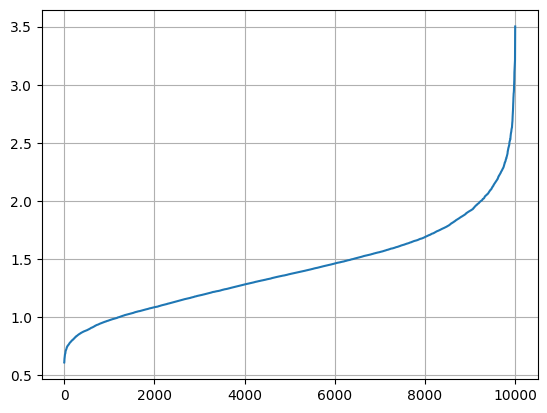

In [29]:
plt.plot(sorted(dist[:, -1]))
plt.grid()
plt.show()

Для eps выберем значение 2, после которого начинается резкий раст графика.

In [ ]:
dbscan = DBSCAN(eps=2, min_samples=10)
df_labels = dbscan.fit_predict(X_cluster)

In [31]:
pd.Series(df_labels).value_counts()

 4    2004
 3    1830
 7    1582
 0    1567
 5     830
 6     733
 1     662
 2     632
-1     160
Name: count, dtype: int64

При eps=2 и min_samples=10 поличили 8 кластеров и один небольшой кластер, включающий точки, которые не были отнесены ни к одному из основных. Дальнейшее увеличение eps ведет к резкому сокращению числа кластеров, тогда как его снижение - к их рост. Изменение параметра min_samples не оказывает заметного влияения на количество кластеров.  

Посмотрим на различие кластеров в разрезе клиентов с оттоком

In [32]:
df['cluster'] = df_labels

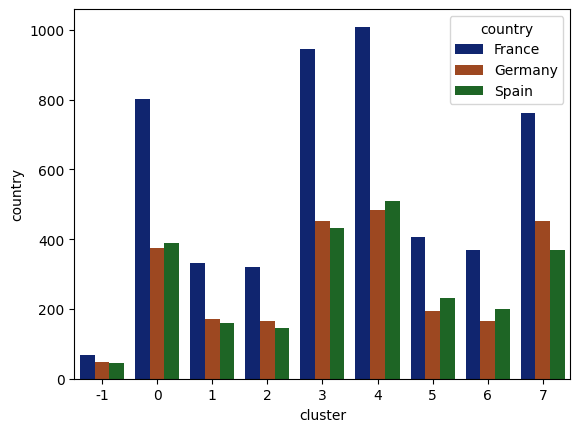

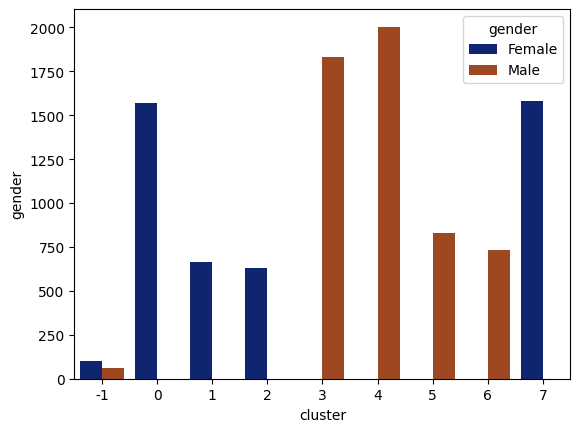

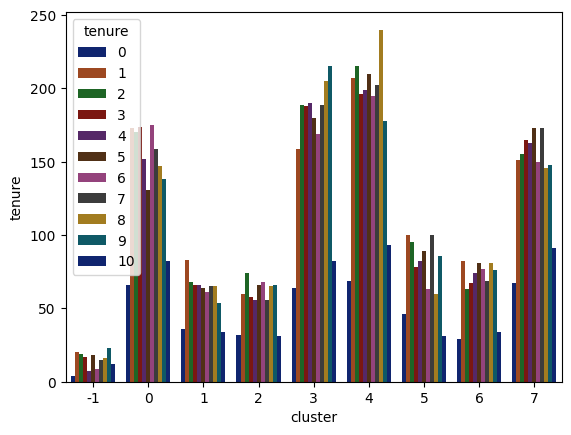

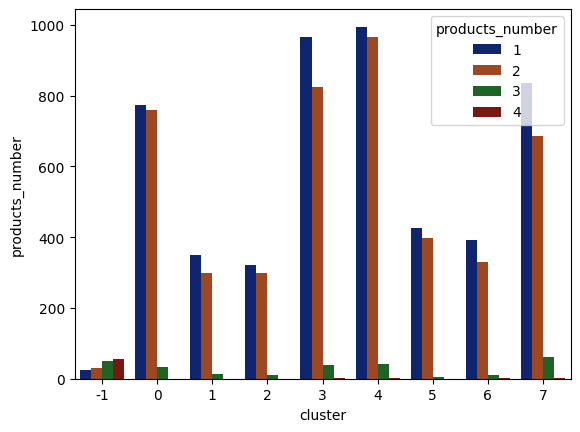

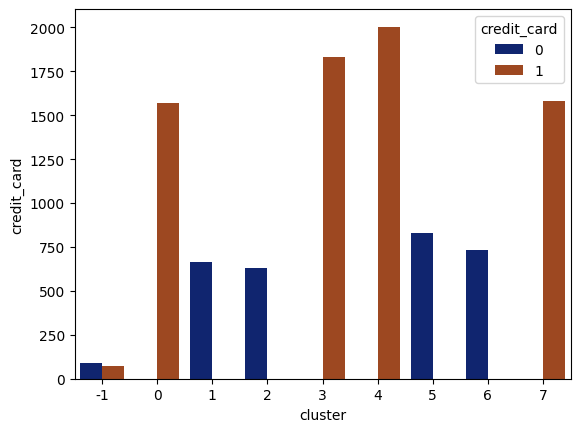

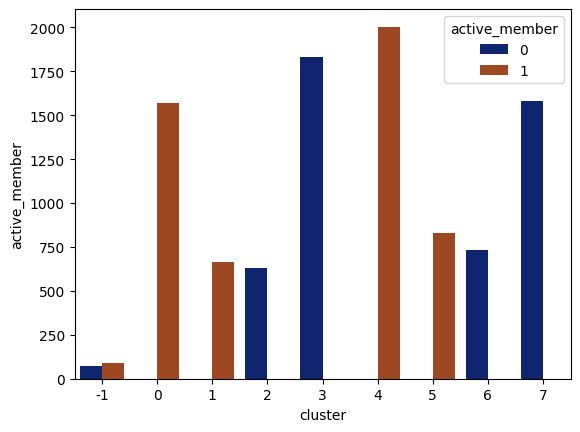

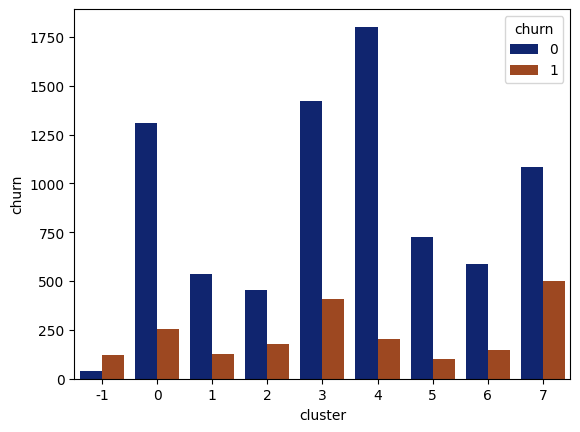

In [33]:
for i in df[cat_col+['churn']]:
    sns.barplot(data=df.groupby(['cluster', i], as_index=False).size(), 
                x='cluster', y='size', hue=i, palette='dark')
    plt.ylabel(i)
    plt.show()

Заметно большое число ушедших пользователей в кластерах 3 и 7 - это не активные клиенты с наличием кредитной карты. В целом кластеры сегментированы по полу, наличию кредитной карты и признаку *active_member*. Например, в кластере 7 наблюдается наибольшее количество ушедших клиентов и самая высокая их доля (почти треть кластера): это женщины, которые не являются *active_member*, но имеющую кредитную карту.